In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils import resample
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier


In [56]:
df = pd.read_csv('E:/Learn_python/lab/AIL/wine-red.csv')
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [57]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


array([[<Axes: title={'center': 'fixed acidity'}>,
        <Axes: title={'center': 'volatile acidity'}>,
        <Axes: title={'center': 'citric acid'}>],
       [<Axes: title={'center': 'residual sugar'}>,
        <Axes: title={'center': 'chlorides'}>,
        <Axes: title={'center': 'free sulfur dioxide'}>],
       [<Axes: title={'center': 'total sulfur dioxide'}>,
        <Axes: title={'center': 'density'}>,
        <Axes: title={'center': 'pH'}>],
       [<Axes: title={'center': 'sulphates'}>,
        <Axes: title={'center': 'alcohol'}>,
        <Axes: title={'center': 'quality'}>]], dtype=object)

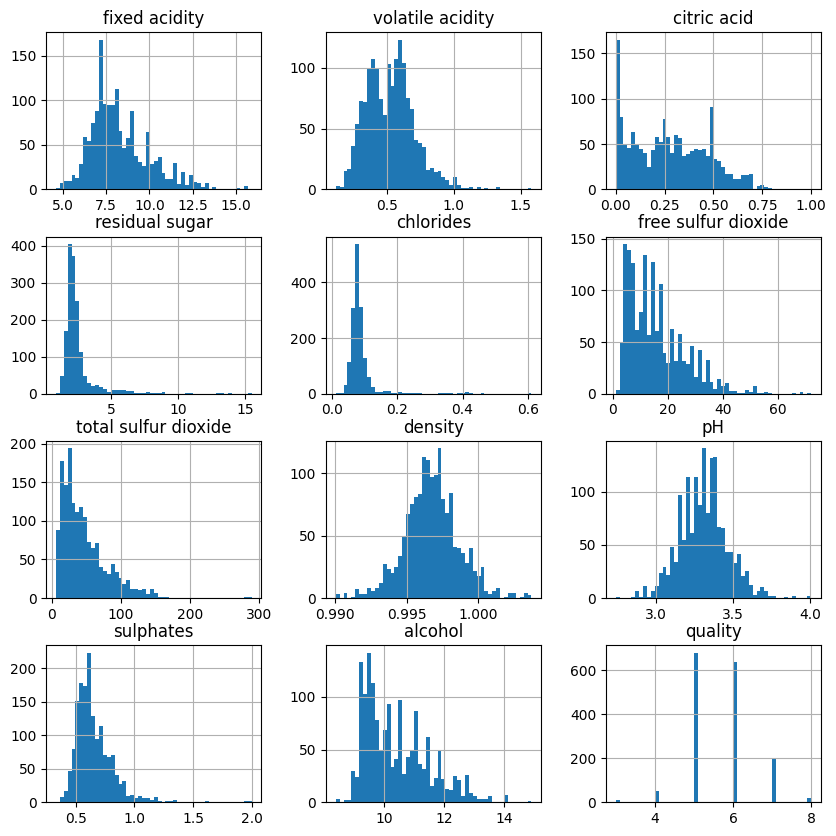

In [59]:
df.hist(figsize=(10,10), bins=50)

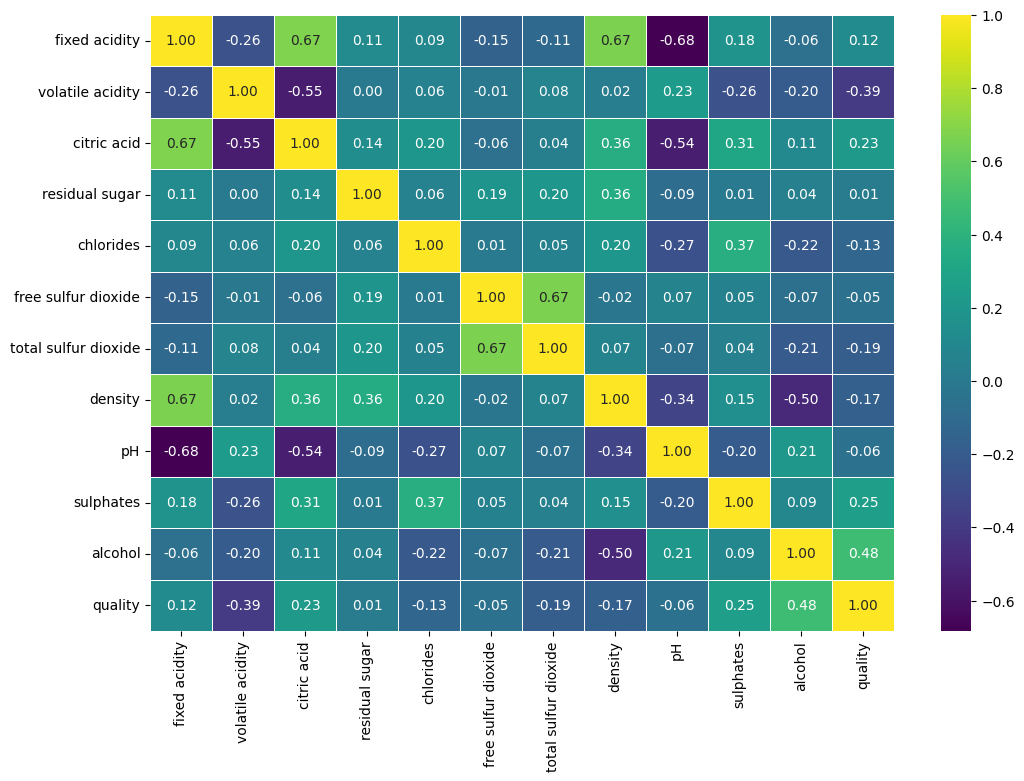

In [60]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), cmap='viridis', annot = True, fmt=".2f", linewidths=0.5)
plt.show()

'quality' có giá trị từ 3 đến 8, với hầu hết các loại rượu được xếp hạng chất lượng 5 (681 mẫu), 6 (638 mẫu) và 7 (199 mẫu). Các lớp 3, 4 và 8 có đáng kể ít mẫu hơn, cho thấy một bộ dữ liệu mất cân bằng

In [61]:
df = df[~df['quality'].isin([3, 4, 8])]
df.reset_index(drop=True, inplace=True)
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1513,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1514,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1515,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1516,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [62]:
wine_data_filtered = df[df['quality'].isin([5, 6, 7])]

class_5 = wine_data_filtered[wine_data_filtered['quality'] == 5]
class_6 = wine_data_filtered[wine_data_filtered['quality'] == 6]
class_7 = wine_data_filtered[wine_data_filtered['quality'] == 7]


class_6_upsampled = resample(class_6, replace=True, n_samples=len(class_5), random_state=42)
class_7_upsampled = resample(class_7, replace=True, n_samples=len(class_5), random_state=42)
wine_data_resampled = pd.concat([class_5, class_6_upsampled, class_7_upsampled])

resampled_distribution = wine_data_resampled['quality'].value_counts()

resampled_distribution

quality
5    681
6    681
7    681
Name: count, dtype: int64

In [63]:
X = wine_data_resampled.drop('quality', axis=1)
y = wine_data_resampled['quality']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr_model = LogisticRegression(max_iter=10000)
lr_model.fit(X_train_scaled, y_train)

y_pred = lr_model.predict(X_test_scaled)
classification_report_results = classification_report(y_test, y_pred)

classification_report_results.split('\n')

['              precision    recall  f1-score   support',
 '',
 '           5       0.74      0.74      0.74       144',
 '           6       0.47      0.38      0.42       128',
 '           7       0.67      0.78      0.72       137',
 '',
 '    accuracy                           0.64       409',
 '   macro avg       0.63      0.64      0.63       409',
 'weighted avg       0.63      0.64      0.63       409',
 '']

In [64]:
knn_model = KNeighborsClassifier()
knn_model.fit(X_train_scaled, y_train)
y_pred_knn = knn_model.predict(X_test_scaled)
classification_report_knn = classification_report(y_test, y_pred_knn)

classification_report_knn.split('\n')

['              precision    recall  f1-score   support',
 '',
 '           5       0.81      0.60      0.69       144',
 '           6       0.60      0.65      0.62       128',
 '           7       0.76      0.90      0.82       137',
 '',
 '    accuracy                           0.72       409',
 '   macro avg       0.72      0.72      0.71       409',
 'weighted avg       0.72      0.72      0.71       409',
 '']

In [65]:
svc_model = SVC()
svc_model.fit(X_train_scaled, y_train)

y_pred_svc = svc_model.predict(X_test_scaled)

classification_report_svc = classification_report(y_test, y_pred_svc)

classification_report_svc.split('\n')

['              precision    recall  f1-score   support',
 '',
 '           5       0.80      0.76      0.78       144',
 '           6       0.56      0.55      0.55       128',
 '           7       0.76      0.81      0.78       137',
 '',
 '    accuracy                           0.71       409',
 '   macro avg       0.70      0.70      0.70       409',
 'weighted avg       0.71      0.71      0.71       409',
 '']

In [66]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_scaled, y_train)

y_pred_rf = rf_model.predict(X_test_scaled)

classification_report_rf = classification_report(y_test, y_pred_rf)

classification_report_rf.split('\n')

['              precision    recall  f1-score   support',
 '',
 '           5       0.92      0.80      0.86       144',
 '           6       0.79      0.84      0.81       128',
 '           7       0.89      0.97      0.93       137',
 '',
 '    accuracy                           0.87       409',
 '   macro avg       0.87      0.87      0.87       409',
 'weighted avg       0.87      0.87      0.87       409',
 '']

In [67]:
et_model = ExtraTreesClassifier(random_state=42)
et_model.fit(X_train_scaled, y_train)

y_pred_et = et_model.predict(X_test_scaled)

classification_report_et = classification_report(y_test, y_pred_et)

classification_report_et.split('\n')

['              precision    recall  f1-score   support',
 '',
 '           5       0.90      0.84      0.87       144',
 '           6       0.81      0.86      0.84       128',
 '           7       0.94      0.96      0.95       137',
 '',
 '    accuracy                           0.89       409',
 '   macro avg       0.89      0.89      0.89       409',
 'weighted avg       0.89      0.89      0.89       409',
 '']

In [68]:

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_scaled, y_train)

y_pred_dt = dt_model.predict(X_test_scaled)

classification_report_dt = classification_report(y_test, y_pred_dt)

classification_report_dt.split('\n')

['              precision    recall  f1-score   support',
 '',
 '           5       0.91      0.73      0.81       144',
 '           6       0.74      0.84      0.79       128',
 '           7       0.89      0.96      0.92       137',
 '',
 '    accuracy                           0.84       409',
 '   macro avg       0.84      0.84      0.84       409',
 'weighted avg       0.85      0.84      0.84       409',
 '']

In [69]:

gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train_scaled, y_train)

y_pred_gb = gb_model.predict(X_test_scaled)

classification_report_gb = classification_report(y_test, y_pred_gb)

classification_report_gb.split('\n')

['              precision    recall  f1-score   support',
 '',
 '           5       0.88      0.72      0.79       144',
 '           6       0.68      0.76      0.72       128',
 '           7       0.85      0.92      0.88       137',
 '',
 '    accuracy                           0.80       409',
 '   macro avg       0.80      0.80      0.80       409',
 'weighted avg       0.81      0.80      0.80       409',
 '']